In [72]:
# from google.colab import files
# uploaded = files.upload()

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/BUSI4370_CW1")

print("Files in DATA_DIR:")
for f in sorted(DATA_DIR.glob("*")):
    print(" -", f.name)

df_customer = pd.read_csv(DATA_DIR / "customers_sample.csv")
df_basket   = pd.read_csv(DATA_DIR / "baskets_sample.csv")
df_category = pd.read_csv(DATA_DIR / "category_spends_sample.csv")
df_items    = pd.read_csv(DATA_DIR / "lineitems_sample.csv")

print("Loaded shapes:",
      df_customer.shape, df_basket.shape, df_category.shape, df_items.shape)

Files in DATA_DIR:
 - baskets_sample.csv
 - category_spends_sample.csv
 - customers_sample.csv
 - lineitems_sample.csv
Loaded shapes: (3000, 6) (195547, 5) (3000, 21) (1461315, 6)


In [76]:
CUSTOMERS_PATH = DATA_DIR / "customers_sample.csv"
BASKETS_PATH   = DATA_DIR / "baskets_sample.csv"
CATEGORY_PATH  = DATA_DIR / "category_spends_sample.csv"
LINEITEMS_PATH = DATA_DIR / "lineitems_sample.csv"

In [77]:
df_customer = pd.read_csv(CUSTOMERS_PATH)
df_basket   = pd.read_csv(BASKETS_PATH)
df_category  = pd.read_csv(CATEGORY_PATH)
df_items     = pd.read_csv(LINEITEMS_PATH)

In [78]:
# df_customer = pd.read_csv("customers_sample.csv")
# df_category  = pd.read_csv("category_spends_sample.csv")
# df_basket  = pd.read_csv("baskets_sample.csv")
# df_items     = pd.read_csv("lineitems_sample.csv")

**Exploratory Data Analysis**

In [79]:
print(df_customer.columns)
print(df_basket.columns)
print(df_category.columns)
print(df_items.columns)

Index(['customer_number', 'baskets', 'total_quantity', 'average_quantity',
       'total_spend', 'average_spend'],
      dtype='object')
Index(['customer_number', 'purchase_time', 'basket_quantity', 'basket_spend',
       'basket_categories'],
      dtype='object')
Index(['customer_number', 'fruit_veg', 'dairy', 'confectionary',
       'grocery_food', 'grocery_health_pets', 'bakery', 'newspapers_magazines',
       'prepared_meals', 'soft_drinks', 'frozen', 'meat', 'tobacco', 'drinks',
       'deli', 'world_foods', 'lottery', 'cashpoint', 'seasonal_gifting',
       'discount_bakery', 'practical_items'],
      dtype='object')
Index(['customer_number', 'purchase_time', 'product_id', 'category',
       'quantity', 'spend'],
      dtype='object')


**Analysis for Customer_Sample file**

In [80]:
df_customer.info()
df_customer


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_number   3000 non-null   int64  
 1   baskets           3000 non-null   int64  
 2   total_quantity    3000 non-null   int64  
 3   average_quantity  3000 non-null   float64
 4   total_spend       3000 non-null   object 
 5   average_spend     3000 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 140.8+ KB


,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,£631.12,£2.87
1,4757,248,333,1.342742,£452.42,£1.82
2,144,226,303,1.340708,£261.16,£1.16
3,572,285,346,1.214035,£638.79,£2.24
4,669,285,324,1.136842,£561.42,£1.97
...,...,...,...,...,...,...
2995,3583,598,705,1.178930,£619.83,£1.04
2996,6434,635,695,1.094488,£877.16,£1.38
2997,9778,1147,1466,1.278117,"£1,754.97",£1.53
2998,8639,262,275,1.049618,£332.89,£1.27


In [81]:
df_customer.describe()

,customer_number,baskets,total_quantity,average_quantity
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,8095.724333,487.105000,583.722000,1.204499
std,4686.259488,332.824524,405.006359,0.136323
min,14.000000,6.000000,6.000000,1.000000
25%,4044.750000,257.000000,307.750000,1.119625
50%,8218.500000,417.000000,495.000000,1.175889
75%,12115.500000,628.250000,744.250000,1.250430
max,16316.000000,3119.000000,4949.000000,2.503686


In [82]:
# for 'total_spend'
# replacing '£' and ',' with an empty string, then converting it into "float" as there data type given is "object"
df_customer['total_spend'] = df_customer['total_spend'].str.replace('£', '', regex=True)
df_customer['total_spend'] = df_customer['total_spend'].str.replace(',', '', regex=True)
df_customer['total_spend'] = df_customer['total_spend'].astype(float)

# for 'average_spend'
df_customer['average_spend'] = df_customer['average_spend'].str.replace('£', '', regex=True)
df_customer['average_spend'] = df_customer['average_spend'].str.replace(',', '', regex=True)
df_customer['average_spend'] = df_customer['average_spend'].astype(float)

In [83]:
df_customer.info()
df_customer.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_number   3000 non-null   int64  
 1   baskets           3000 non-null   int64  
 2   total_quantity    3000 non-null   int64  
 3   average_quantity  3000 non-null   float64
 4   total_spend       3000 non-null   float64
 5   average_spend     3000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 140.8 KB


,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,631.12,2.87
1,4757,248,333,1.342742,452.42,1.82
2,144,226,303,1.340708,261.16,1.16
3,572,285,346,1.214035,638.79,2.24
4,669,285,324,1.136842,561.42,1.97
5,792,830,857,1.032530,1267.05,1.53
6,928,276,294,1.065217,1074.51,3.89
7,1031,60,69,1.150000,84.46,1.41
8,1079,1040,1273,1.224038,1730.24,1.66
9,1325,191,214,1.120419,441.80,2.31


**Analysis for basket file**

In [84]:
df_basket.info()
df_basket


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195547 entries, 0 to 195546
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   customer_number    195547 non-null  int64 
 1   purchase_time      195547 non-null  object
 2   basket_quantity    195547 non-null  int64 
 3   basket_spend       195547 non-null  object
 4   basket_categories  195547 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 7.5+ MB


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,£3.09,3
1,4047,2007-03-01 07:13:00,9,£7.99,5
2,3571,2007-03-01 07:27:00,9,£37.06,6
3,4079,2007-03-01 07:34:00,11,£11.91,5
4,6063,2007-03-01 07:36:00,3,£1.45,1
...,...,...,...,...,...
195542,5107,2007-08-31 21:40:00,6,£9.66,3
195543,1988,2007-08-31 21:45:00,12,£14.98,6
195544,3028,2007-08-31 21:46:00,6,£6.21,2
195545,7191,2007-08-31 21:46:00,7,£6.30,3


In [85]:
# for 'basket_spend'
# replacing '£' and ',' with an empty string, then converting it into "float" as there data type given is "object"
df_basket['basket_spend'] = df_basket['basket_spend'].str.replace('£', '', regex=True)
df_basket['basket_spend'] = df_basket['basket_spend'].str.replace(',', '', regex=True)
df_basket['basket_spend'] = df_basket['basket_spend'].astype(float)

# changing data type of column 'purchase_time' to 'datetime'

df_basket['purchase_time'] = pd.to_datetime(df_basket['purchase_time'])

In [86]:
df_basket.info()
df_basket.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195547 entries, 0 to 195546
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_number    195547 non-null  int64         
 1   purchase_time      195547 non-null  datetime64[ns]
 2   basket_quantity    195547 non-null  int64         
 3   basket_spend       195547 non-null  float64       
 4   basket_categories  195547 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 7.5 MB


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,3.09,3
1,4047,2007-03-01 07:13:00,9,7.99,5
2,3571,2007-03-01 07:27:00,9,37.06,6
3,4079,2007-03-01 07:34:00,11,11.91,5
4,6063,2007-03-01 07:36:00,3,1.45,1
5,6177,2007-03-01 07:37:00,11,12.54,9
6,5467,2007-03-01 07:39:00,2,1.70,2
7,263,2007-03-01 07:48:00,3,1.84,2
8,4745,2007-03-01 07:55:00,4,2.41,2
9,10613,2007-03-01 08:01:00,7,6.08,4


In [87]:
df_basket[['basket_quantity','basket_spend','basket_categories']].describe(percentiles=[.01,.05,.95,.99])


,basket_quantity,basket_spend,basket_categories
count,195547.000000,195547.000000,195547.000000
mean,8.955218,11.804010,4.231990
std,9.510890,13.031542,2.478016
min,-11.000000,-98.400000,1.000000
1%,1.000000,0.720000,1.000000
5%,1.000000,1.550000,1.000000
50%,6.000000,8.130000,4.000000
95%,26.000000,34.520000,9.000000
99%,49.000000,64.915400,11.000000
max,190.000000,377.280000,16.000000


In [88]:
# checking how many negative vlaues are there
(df_basket['basket_quantity'] < 0).sum()
(df_basket['basket_spend'] < 0).sum()

np.int64(160)

In [89]:
# Replacing Negative values with zero
df_basket.loc[df_basket["basket_spend"] < 0, "basket_spend"] = 0.0
df_basket.loc[df_basket["basket_quantity"] < 0, "basket_quantity"] = 0



In [90]:
df_basket.describe()

,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
count,195547.000000,195547,195547.000000,195547.000000,195547.000000
mean,7896.492899,2007-05-29 17:51:12.741182720,8.955504,11.809666,4.231990
min,14.000000,2007-03-01 07:06:00,0.000000,0.000000,1.000000
25%,4323.000000,2007-04-13 13:37:00,3.000000,4.280000,2.000000
50%,7944.000000,2007-05-28 14:33:00,6.000000,8.130000,4.000000
75%,11324.000000,2007-07-13 20:11:00,11.000000,14.480000,6.000000
max,16316.000000,2007-08-31 21:55:00,190.000000,377.280000,16.000000
std,4408.251411,NaN,9.510536,13.020956,2.478016


**Analysis for Category file**

In [91]:
df_category.info()
df_category

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_number       3000 non-null   int64 
 1   fruit_veg             3000 non-null   object
 2   dairy                 3000 non-null   object
 3   confectionary         3000 non-null   object
 4   grocery_food          3000 non-null   object
 5   grocery_health_pets   3000 non-null   object
 6   bakery                3000 non-null   object
 7   newspapers_magazines  3000 non-null   object
 8   prepared_meals        3000 non-null   object
 9   soft_drinks           3000 non-null   object
 10  frozen                3000 non-null   object
 11  meat                  3000 non-null   object
 12  tobacco               3000 non-null   object
 13  drinks                3000 non-null   object
 14  deli                  3000 non-null   object
 15  world_foods           3000 non-null   

,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,...,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,£64.58,£35.91,£107.78,£27.08,£29.59,£0.00,£54.83,£6.35,£22.83,...,£28.62,£162.10,£28.02,£28.12,£28.54,£2.00,£15.00,£7.48,£0.00,£0.84
1,8171,£16.89,£37.24,£28.84,£33.43,£66.40,£0.00,£22.06,£12.09,£2.34,...,£26.44,£0.00,£8.42,£2.65,£3.76,£0.00,£0.00,£9.99,£0.00,£0.00
2,1060,£87.30,£82.98,£49.88,£20.57,£37.04,£0.00,£9.85,£57.98,£31.12,...,£54.65,£0.00,£0.00,£2.60,£0.00,£18.00,£20.00,£106.46,£0.00,£0.00
3,3728,£84.05,£186.56,£175.50,£119.84,£111.08,£0.00,£13.05,£25.54,£124.42,...,£0.95,£127.70,£0.00,£0.00,£0.00,£4.00,£0.00,£0.00,£0.00,£4.50
4,14621,£35.16,£121.31,£79.23,£29.03,£37.17,£0.00,£40.06,£0.00,£4.68,...,£36.24,£0.00,£2.55,£99.16,£0.00,£0.00,£0.00,£3.40,£0.00,£0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,12541,£64.52,£73.84,£89.36,£135.31,£61.99,£0.00,£0.00,£61.02,£56.62,...,£58.78,£36.57,£0.00,£0.00,£3.36,£0.00,£0.00,£0.00,£0.00,£2.53
2996,16081,£5.91,£18.08,£18.32,£23.69,£16.12,£0.00,£5.39,£15.96,£0.67,...,£0.00,£50.54,£0.00,£7.73,£9.74,£30.00,£0.00,£0.00,£0.00,£1.61
2997,7094,£116.54,£106.08,£42.31,£35.92,£43.59,£0.00,£13.68,£1.78,£21.44,...,£21.51,£0.00,£7.65,£4.10,£2.59,£0.00,£0.00,£0.00,£0.00,£6.79
2998,3457,£3.68,£13.44,£21.96,£10.10,£12.51,£0.00,£4.75,£1.04,£4.33,...,£4.66,£0.00,£0.00,£8.27,£1.65,£0.00,£0.00,£1.98,£0.00,£0.00


In [92]:
df_category.columns

Index(['customer_number', 'fruit_veg', 'dairy', 'confectionary',
       'grocery_food', 'grocery_health_pets', 'bakery', 'newspapers_magazines',
       'prepared_meals', 'soft_drinks', 'frozen', 'meat', 'tobacco', 'drinks',
       'deli', 'world_foods', 'lottery', 'cashpoint', 'seasonal_gifting',
       'discount_bakery', 'practical_items'],
      dtype='object')

In [93]:
category_columns = df_category.columns[1:]

# using Loop to each each column and cchanging its data type to float
for c in category_columns:
    df_category[c] = df_category[c].str.replace('£', '', regex=True)
    df_category[c] = df_category[c].str.replace(',', '', regex=True)
    df_category[c] = df_category[c].astype(float)

In [94]:
df_category.info()
df_category.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_number       3000 non-null   int64  
 1   fruit_veg             3000 non-null   float64
 2   dairy                 3000 non-null   float64
 3   confectionary         3000 non-null   float64
 4   grocery_food          3000 non-null   float64
 5   grocery_health_pets   3000 non-null   float64
 6   bakery                3000 non-null   float64
 7   newspapers_magazines  3000 non-null   float64
 8   prepared_meals        3000 non-null   float64
 9   soft_drinks           3000 non-null   float64
 10  frozen                3000 non-null   float64
 11  meat                  3000 non-null   float64
 12  tobacco               3000 non-null   float64
 13  drinks                3000 non-null   float64
 14  deli                  3000 non-null   float64
 15  world_foods          

,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,...,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,64.58,35.91,107.78,27.08,29.59,0.0,54.83,6.35,22.83,...,28.62,162.1,28.02,28.12,28.54,2.0,15.0,7.48,0.00,0.84
1,8171,16.89,37.24,28.84,33.43,66.40,0.0,22.06,12.09,2.34,...,26.44,0.0,8.42,2.65,3.76,0.0,0.0,9.99,0.00,0.00
2,1060,87.30,82.98,49.88,20.57,37.04,0.0,9.85,57.98,31.12,...,54.65,0.0,0.00,2.60,0.00,18.0,20.0,106.46,0.00,0.00
3,3728,84.05,186.56,175.50,119.84,111.08,0.0,13.05,25.54,124.42,...,0.95,127.7,0.00,0.00,0.00,4.0,0.0,0.00,0.00,4.50
4,14621,35.16,121.31,79.23,29.03,37.17,0.0,40.06,0.00,4.68,...,36.24,0.0,2.55,99.16,0.00,0.0,0.0,3.40,0.00,0.00
5,12563,25.76,19.11,20.84,37.29,8.99,0.0,0.00,17.65,14.48,...,17.32,0.0,36.74,5.50,3.73,0.0,0.0,0.00,11.28,0.00
6,1652,97.60,31.16,21.50,47.13,26.29,0.0,4.12,24.92,1.26,...,31.96,0.0,0.00,0.00,9.83,0.0,0.0,0.00,0.00,0.00
7,2989,52.82,51.56,51.92,63.79,61.78,0.0,15.35,24.52,22.16,...,47.08,0.0,0.00,10.46,19.10,0.0,20.0,1.70,0.00,5.08
8,14219,126.27,132.41,35.54,84.98,23.47,0.0,0.00,9.99,9.63,...,14.60,0.0,0.00,0.89,4.56,0.0,0.0,0.00,0.00,0.00
9,1831,2.77,16.40,47.54,16.86,5.42,0.0,9.42,5.43,1.57,...,4.52,0.0,2.97,0.55,0.00,9.0,44.0,0.00,0.00,0.00


In [95]:
df_category.describe()

,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,...,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.00000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,8095.724333,69.456163,71.302683,57.347793,60.007530,60.909867,0.0,16.653390,35.48057,23.303350,...,54.740687,92.547613,62.242217,13.736440,8.554260,14.165603,45.330583,6.126987,1.814837,2.016220
std,4686.259488,70.499654,57.966265,55.959350,57.682533,69.805023,0.0,26.377091,41.24047,35.695592,...,67.802126,201.703812,121.500365,25.486136,14.757745,48.469754,123.584361,13.104271,9.450367,4.322232
min,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-74.000000,0.000000,0.000000,0.000000,0.000000
25%,4044.750000,22.695000,31.390000,21.070000,21.087500,18.145000,0.0,1.500000,8.70000,3.750000,...,12.640000,0.000000,0.000000,0.000000,0.890000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8218.500000,50.935000,56.875000,42.290000,44.030000,39.075000,0.0,7.345000,23.09500,11.685000,...,32.930000,2.030000,12.830000,3.495000,3.760000,0.000000,0.000000,1.990000,0.000000,0.000000
75%,12115.500000,93.405000,95.327500,75.125000,80.922500,77.250000,0.0,19.687500,47.33000,28.782500,...,72.380000,81.030000,65.150000,15.770000,10.647500,6.000000,30.000000,6.720000,0.000000,2.510000
max,16316.000000,1262.970000,708.040000,614.370000,1017.070000,884.450000,0.0,351.730000,454.29000,529.650000,...,713.280000,2488.940000,1005.330000,316.190000,321.490000,946.000000,2137.010000,229.440000,173.060000,65.060000


In [96]:
# checking how many negative values are there in lottery column
(df_category['lottery'] < 0).sum()

np.int64(29)

In [97]:
# Replacing negative values with zero
df_category.loc[df_category['lottery'] < 0, 'lottery'] = 0.0

In [98]:
(df_category['lottery'] < 0).sum()
df_category.describe(percentiles=[.01,.05,.95,.99])

,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,...,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.00000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,8095.724333,69.456163,71.302683,57.347793,60.007530,60.909867,0.0,16.653390,35.48057,23.303350,...,54.740687,92.547613,62.242217,13.736440,8.554260,14.259137,45.330583,6.126987,1.814837,2.016220
std,4686.259488,70.499654,57.966265,55.959350,57.682533,69.805023,0.0,26.377091,41.24047,35.695592,...,67.802126,201.703812,121.500365,25.486136,14.757745,48.412934,123.584361,13.104271,9.450367,4.322232
min,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,181.940000,0.768600,2.279700,1.149100,0.929800,0.000000,0.0,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5%,776.650000,4.659500,8.438000,5.369500,5.447000,2.928000,0.0,0.000000,0.59000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8218.500000,50.935000,56.875000,42.290000,44.030000,39.075000,0.0,7.345000,23.09500,11.685000,...,32.930000,2.030000,12.830000,3.495000,3.760000,0.000000,0.000000,1.990000,0.000000,0.000000
95%,15391.150000,202.420500,184.495000,165.319500,166.436500,194.146000,0.0,65.432500,112.32400,87.132500,...,175.612000,515.601000,300.746500,62.329500,30.193500,74.000000,258.765000,24.710000,8.252500,9.858500
99%,16117.080000,336.009400,272.003900,273.361400,260.315700,317.825700,0.0,119.630400,194.44100,162.875900,...,331.581500,900.514500,647.003400,124.420600,64.041400,247.570000,540.095000,58.756800,46.704600,19.576100
max,16316.000000,1262.970000,708.040000,614.370000,1017.070000,884.450000,0.0,351.730000,454.29000,529.650000,...,713.280000,2488.940000,1005.330000,316.190000,321.490000,946.000000,2137.010000,229.440000,173.060000,65.060000


**Analysis for Lineitems file**

In [99]:
df_items.info()
df_items

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461315 entries, 0 to 1461314
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   customer_number  1461315 non-null  int64 
 1   purchase_time    1461315 non-null  object
 2   product_id       1461315 non-null  int64 
 3   category         1461315 non-null  object
 4   quantity         1461315 non-null  int64 
 5   spend            1461315 non-null  object
dtypes: int64(3), object(3)
memory usage: 66.9+ MB


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,£1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,£4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,£0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,£0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,£1.59
...,...,...,...,...,...,...
1461310,11585,2007-08-21 11:59:00,730790,PRACTICAL_ITEMS,1,£3.40
1461311,7329,2007-08-30 19:34:00,730790,PRACTICAL_ITEMS,1,£3.40
1461312,1129,2007-08-30 16:51:00,730798,PRACTICAL_ITEMS,3,£10.19
1461313,5060,2007-08-11 16:30:00,730798,PRACTICAL_ITEMS,2,£6.79


In [100]:
#changing 'purchas_time'  columns datatype to datetime
df_items['purchase_time'] = pd.to_datetime(df_items['purchase_time'])

# replacing '£' and ',' with an empty string, then converting it into "float" as there data type given is "object"
df_items['spend'] = df_items['spend'].str.replace('£', '', regex=True).str.replace(',', '', regex=True).astype(float)


In [101]:
df_items.info()
df_items.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461315 entries, 0 to 1461314
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   customer_number  1461315 non-null  int64         
 1   purchase_time    1461315 non-null  datetime64[ns]
 2   product_id       1461315 non-null  int64         
 3   category         1461315 non-null  object        
 4   quantity         1461315 non-null  int64         
 5   spend            1461315 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 66.9+ MB


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,1.59
5,9269,2007-03-27 12:52:00,700756,PREPARED_MEALS,1,2.00
6,6798,2007-03-14 20:27:00,663033,PREPARED_MEALS,2,3.00
7,10248,2007-03-30 15:21:00,731976,FROZEN,1,1.50
8,10222,2007-03-16 12:24:00,48565,FROZEN,1,1.99
9,7401,2007-03-20 19:44:00,131436,SEASONAL_GIFTING,1,1.69


In [102]:
df_items[['quantity','spend']].describe()


,quantity,spend
count,1.461315e+06,1.461315e+06
mean,1.198349e+00,1.579563e+00
std,5.990824e-01,2.576834e+00
min,-1.300000e+01,-1.000000e+02
25%,1.000000e+00,6.800000e-01
50%,1.000000e+00,1.030000e+00
75%,1.000000e+00,1.730000e+00
max,1.000000e+02,3.600000e+02


In [103]:
# checking how much negative value are there
(df_items['quantity'] < 0).sum()
(df_items['spend'] < 0).sum()

np.int64(864)

In [104]:
# Repalcing Negative values with zero
df_items.loc[df_items["spend"] < 0, "spend"] = 0.0
df_items.loc[df_items["quantity"] < 0, "quantity"] = 0



In [105]:
df_items[['quantity','spend']].describe()

,quantity,spend
count,1.461315e+06,1.461315e+06
mean,1.199023e+00,1.583058e+00
std,5.965670e-01,2.564342e+00
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,6.800000e-01
50%,1.000000e+00,1.030000e+00
75%,1.000000e+00,1.730000e+00
max,1.000000e+02,3.600000e+02


**Fixation of 'Bakery' column in category table as data in category_spends table was incorrectly recorded**

In [106]:
#Aggregate Bakery Spend from df_items

bakery_from_items = (
    df_items[df_items["category"].astype(str).str.upper().eq("BAKERY")]
    .groupby("customer_number")["spend"]
    .sum()
)


In [107]:
# Convert item spends if they are £ strings (safe even if already numeric)
if df_items["spend"].dtype == "object":
    s = (df_items["spend"].astype(str)
         .str.replace("£", "", regex=False)
         .str.replace(",", "", regex=False)
         .str.strip())
    df_items["spend"] = pd.to_numeric(s, errors="coerce").fillna(0.0)
    bakery_from_items = (
        df_items[df_items["category"].astype(str).str.upper().eq("BAKERY")]
        .groupby("customer_number")["spend"]
        .sum()
    )


In [108]:
# copy for appendix
df_category["bakery_original"] = df_category["bakery"]

# Overwrite bakery with lineitem-derived value (customers without bakery purchases become 0)
df_category["bakery"] = df_category["customer_number"].map(bakery_from_items).fillna(0.0)



In [109]:
# Changes in bakery column
diff = (df_category["bakery"] - df_category["bakery_original"]).abs()
print("Customers whose bakery changed:", (diff > 1e-6).sum(), "out of", len(df_category))
print("Top 5 biggest changes:")
display(df_category.loc[diff.sort_values(ascending=False).head(5).index,
                        ["customer_number","bakery_original","bakery"]])

Customers whose bakery changed: 2963 out of 3000
Top 5 biggest changes:


,customer_number,bakery_original,bakery
1573,11401,0.0,444.37
1538,13793,0.0,430.50
963,2067,0.0,353.05
1166,12221,0.0,335.01
1765,11511,0.0,314.28


In [110]:
df_category['bakery'].describe()

,bakery
count,3000.000000
mean,38.210123
std,36.496115
min,0.000000
25%,14.635000
50%,29.270000
75%,50.050000
max,444.370000


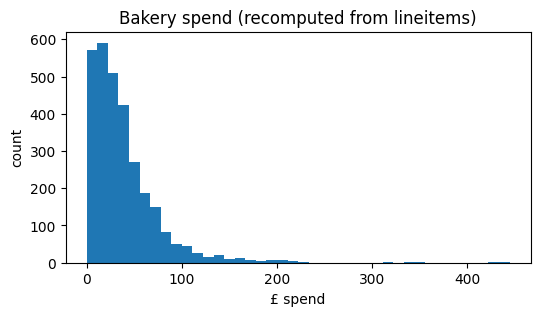

In [111]:
plt.figure(figsize=(6,3))
plt.hist(df_category["bakery"], bins=40)
plt.title("Bakery spend (recomputed from lineitems)")
plt.xlabel("£ spend")
plt.ylabel("count")
plt.show()

In [112]:
import numpy as np

# 1) Negative-value audit (category spends)
neg_counts = (df_category.select_dtypes(include=[np.number]) < 0).sum().sort_values(ascending=False)
print("Negative counts per numeric column in df_category (top 10):")
print(neg_counts.head(10))

# 2) Bakery sanity check
print("\nBakery summary (df_category['bakery']):")
print(df_category["bakery"].describe())
print("Bakery zeros:", (df_category["bakery"] == 0).sum(), "out of", len(df_category))

# 3) Checking NaNs in bakery
print("Bakery NaNs:", df_category["bakery"].isna().sum())

Negative counts per numeric column in df_category (top 10):
customer_number         0
fruit_veg               0
dairy                   0
confectionary           0
grocery_food            0
grocery_health_pets     0
bakery                  0
newspapers_magazines    0
prepared_meals          0
soft_drinks             0
dtype: int64

Bakery summary (df_category['bakery']):
count    3000.000000
mean       38.210123
std        36.496115
min         0.000000
25%        14.635000
50%        29.270000
75%        50.050000
max       444.370000
Name: bakery, dtype: float64
Bakery zeros: 37 out of 3000
Bakery NaNs: 0


Data Preparation

In [113]:
# Aggregate baskets to customer level + merging master feature table

import pandas as pd
import numpy as np

# Ensuring purchase_time is datetime (so that it can be used for recency and spread features)
df_basket["purchase_time"] = pd.to_datetime(df_basket["purchase_time"], errors="coerce")

basket_agg = (
    df_basket.groupby("customer_number")
    .agg(
        n_baskets=("purchase_time", "count"),
        total_basket_qty=("basket_quantity", "sum"),
        avg_basket_qty=("basket_quantity", "mean"),
        std_basket_qty=("basket_quantity", "std"),
        total_basket_spend=("basket_spend", "sum"),
        avg_basket_spend=("basket_spend", "mean"),
        std_basket_spend=("basket_spend", "std"),
        max_basket_spend=("basket_spend", "max"),
        avg_basket_categories=("basket_categories", "mean"),
        std_basket_categories=("basket_categories", "std"),
        active_days=("purchase_time", lambda s: s.dt.date.nunique()),
        first_purchase=("purchase_time", "min"),
        last_purchase=("purchase_time", "max"),
    )
    .reset_index()
)

# Recency (days since last purchase) relative to the dataset max date
max_date = df_basket["purchase_time"].max()
basket_agg["recency_days"] = (max_date - basket_agg["last_purchase"]).dt.days

# Tenure (span between first and last purchase)
basket_agg["tenure_days"] = (basket_agg["last_purchase"] - basket_agg["first_purchase"]).dt.days.clip(lower=0)

# Droping raw datetime columns (keeping recency/tenure instead)
basket_agg = basket_agg.drop(columns=["first_purchase", "last_purchase"])

# Merge of customer base + basket features + category spends
df_model = (
    df_customer
    .merge(basket_agg, on="customer_number", how="left")
    .merge(df_category, on="customer_number", how="left")
)

print("df_model shape:", df_model.shape)
print("Any missing customers after merge?", df_model["customer_number"].isna().sum())
display(df_model.head(3))

df_model shape: (3000, 40)
Any missing customers after merge? 0


,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend,n_baskets,total_basket_qty,avg_basket_qty,std_basket_qty,...,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items,bakery_original
0,4749,220,260,1.181818,631.12,2.87,92,260,2.826087,1.947716,...,1.68,124.88,0.00,0.00,0.0,290.0,0.00,0.0,2.2,0.0
1,4757,248,333,1.342742,452.42,1.82,27,333,12.333333,8.227534,...,4.66,21.84,14.19,0.00,0.0,0.0,2.71,0.0,0.0,0.0
2,144,226,303,1.340708,261.16,1.16,22,303,13.772727,3.778786,...,0.00,2.55,3.80,21.18,0.0,0.0,1.27,0.0,0.0,0.0


In [114]:
import numpy as np

# Droping  non-feature columns
# bakery_original was only for evidence , not for cluster
drop_cols = ["bakery_original"]
df_model_clean = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# Handling NaNs from std calculations (customers with 0/1 baskets)
std_cols = [c for c in df_model_clean.columns if c.startswith("std_")]
df_model_clean[std_cols] = df_model_clean[std_cols].fillna(0.0)

# Sanity check for any remaining NaNs
nan_counts = df_model_clean.isna().sum().sort_values(ascending=False)
print("Top NaN columns:")
print(nan_counts.head(10))

# Removing exact duplicates / constant columns before scaling
nunique = df_model_clean.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
print("\nConstant columns:", const_cols)

if const_cols:
    df_model_clean = df_model_clean.drop(columns=const_cols)

print("\nClean shape:", df_model_clean.shape)

Top NaN columns:
customer_number     0
baskets             0
total_quantity      0
average_quantity    0
total_spend         0
average_spend       0
n_baskets           0
total_basket_qty    0
avg_basket_qty      0
std_basket_qty      0
dtype: int64

Constant columns: []

Clean shape: (3000, 39)


**Drop redundant columns**

In [115]:
#Droping redundant customer summary columns (they duplicate basket aggregates)

redundant = [
    "baskets",           # duplicates n_baskets
    "total_quantity",    # duplicates total_basket_qty
    "average_quantity",  # duplicates avg_basket_qty
    "total_spend",       # duplicates total_basket_spend
    "average_spend"      # duplicates avg_basket_spend
]

df_feat = df_model_clean.drop(columns=[c for c in redundant if c in df_model_clean.columns])

print("After dropping redundant columns:", df_feat.shape)
print("Dropped:", [c for c in redundant if c in df_model_clean.columns])

After dropping redundant columns: (3000, 34)
Dropped: ['baskets', 'total_quantity', 'average_quantity', 'total_spend', 'average_spend']


In [116]:
# Correlation screen and to_drop list

import numpy as np
import pandas as pd

key = "customer_number"

X = df_feat.drop(columns=[key])

corr = X.corr()

# Using 0.95 as primary threshold
threshold = 0.95

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col].abs() > threshold)]

# Top correlated pairs table (for appendix)
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0":"feat1","level_1":"feat2",0:"corr"})
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
)

print("Number of features before:", X.shape[1])
print("Number of features to drop (|corr| > %.2f):" % threshold, len(to_drop))
print("First 25 drops:", to_drop[:25])

display(pairs.head(15))

Number of features before: 33
Number of features to drop (|corr| > 0.95): 2
First 25 drops: ['active_days', 'tenure_days']


,feat1,feat2,corr
297,recency_days,tenure_days,-0.972643
9,n_baskets,active_days,0.956851
65,avg_basket_qty,avg_basket_spend,0.915007
34,total_basket_qty,total_basket_spend,0.879076
177,std_basket_spend,max_basket_spend,0.864086
68,avg_basket_qty,avg_basket_categories,0.850561
95,std_basket_qty,std_basket_spend,0.824170
44,total_basket_qty,dairy,0.779370
98,std_basket_qty,std_basket_categories,0.775528
63,avg_basket_qty,std_basket_qty,0.774839


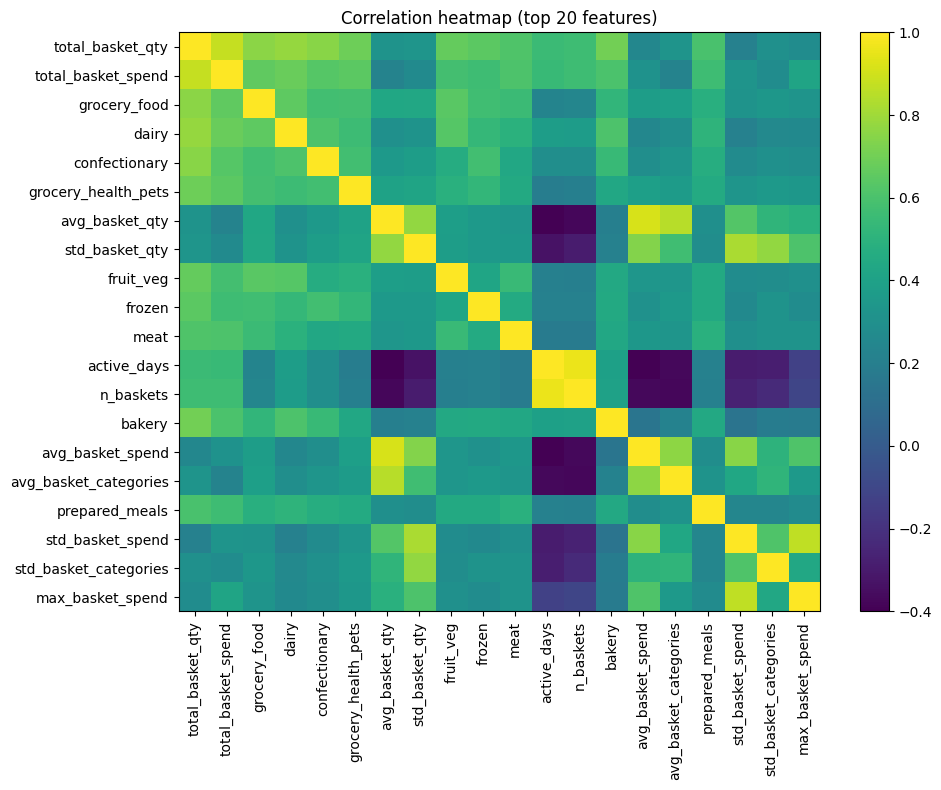

In [117]:
import matplotlib.pyplot as plt

# top 20 features by overall correlation magnitude
top_feats = corr.abs().sum().sort_values(ascending=False).head(20).index
corr_top = corr.loc[top_feats, top_feats]

plt.figure(figsize=(10,8))
plt.imshow(corr_top, aspect="auto")
plt.xticks(range(len(top_feats)), top_feats, rotation=90)
plt.yticks(range(len(top_feats)), top_feats)
plt.colorbar()
plt.title("Correlation heatmap (top 20 features)")
plt.tight_layout()
plt.show()

In [118]:
#Droping highly correlated columns (keeping recency_days + n_baskets)

drops = ["tenure_days", "active_days"]

X = df_feat.drop(columns=["customer_number"])
X = X.drop(columns=[c for c in drops if c in X.columns])

print("Shape after correlation drop:", X.shape)
print("Dropped:", drops)

Shape after correlation drop: (3000, 31)
Dropped: ['tenure_days', 'active_days']


Scaling features and creating a PCA view

X_scaled shape: (3000, 31)


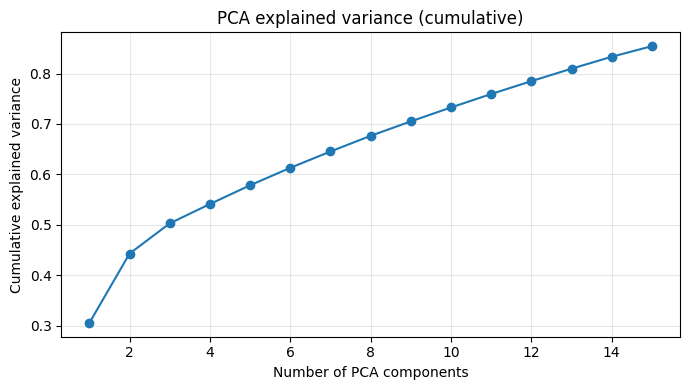

Components for >=80% variance: 13
Components for >=90% variance: 1


In [119]:
# Scaling + PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)

# using PCA
pca = PCA(n_components=min(15, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)

expl = pca.explained_variance_ratio_
cum = np.cumsum(expl)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (cumulative)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# checking how many components for 80% and 90%
k80 = int(np.argmax(cum >= 0.80) + 1)
k90 = int(np.argmax(cum >= 0.90) + 1)
print("Components for >=80% variance:", k80)
print("Components for >=90% variance:", k90)

That >=90% variance: 1 is a math bug in the code logic, not a real PCA result.

What happened: limiting PCA to 15 components. If the cumulative variance never reaches 0.90 within those 15, then np.argmax(cum >= 0.90) returns 0 (because there are no True values), and +1 incorrectly prints 1.

 — fixing the PCA variance calculation (robust)
Running this cell  will compute PCA with all components and handles the “never reaches” case

Total components: 31
Cumulative variance at 15 comps: 0.8543937407090793
Cumulative variance at final comp: 1.0000000000000002
Components for >=80%: 13
Components for >=90%: 18


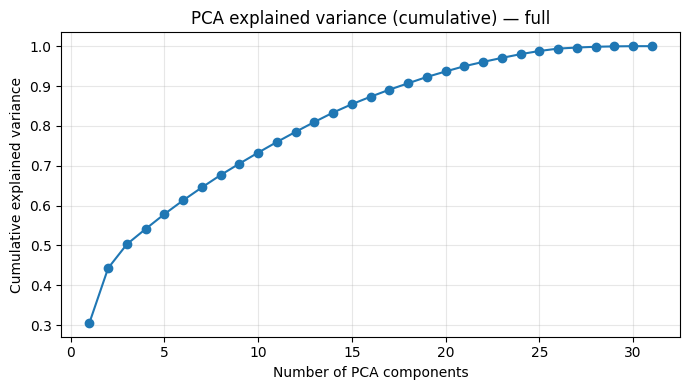

In [120]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA(n_components=None, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

expl = pca_full.explained_variance_ratio_
cum = np.cumsum(expl)

def comps_for(target):
    idx = np.where(cum >= target)[0]
    return int(idx[0] + 1) if len(idx) else None

k80 = comps_for(0.80)
k90 = comps_for(0.90)

print("Total components:", len(cum))
print("Cumulative variance at 15 comps:", cum[14])
print("Cumulative variance at final comp:", cum[-1])
print("Components for >=80%:", k80)
print("Components for >=90%:", k90)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (cumulative) — full")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**k (Elbow + Silhouette plots)**

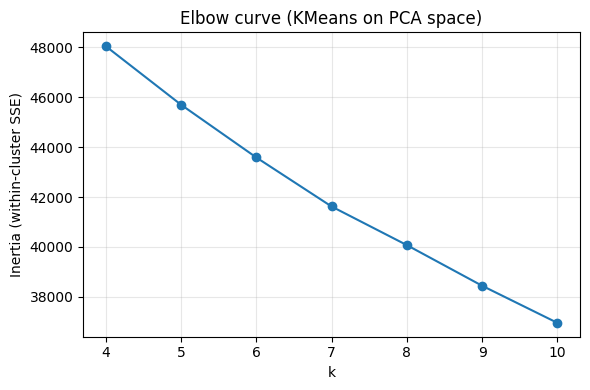

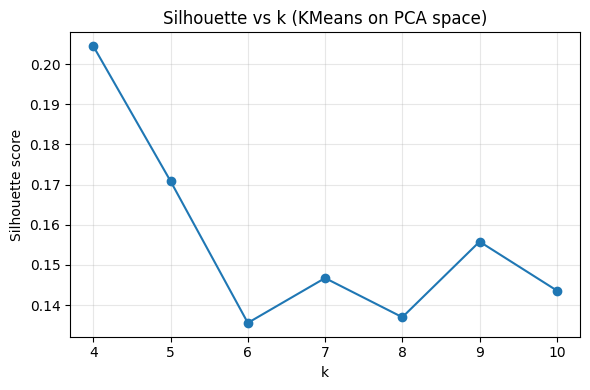

k=4: silhouette=0.204
k=5: silhouette=0.171
k=6: silhouette=0.136
k=7: silhouette=0.147
k=8: silhouette=0.137
k=9: silhouette=0.156
k=10: silhouette=0.144


In [121]:
# KMeans model selection: elbow + silhouette for k=4 - 10

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

#clustering on PCA space to reduce noise + correlation.

n_comp = 13
X_cluster = X_pca_full[:, :n_comp]

ks = list(range(4, 11))
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

# Elbow plot
plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow curve (KMeans on PCA space)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Silhouette vs k plot
plt.figure(figsize=(6,4))
plt.plot(ks, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (KMeans on PCA space)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, s in zip(ks, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

**final KMeans (k=5)**

Final silhouette: 0.171

Cluster sizes:
0    1351
1      91
2     224
3     771
4     563
Name: count, dtype: int64


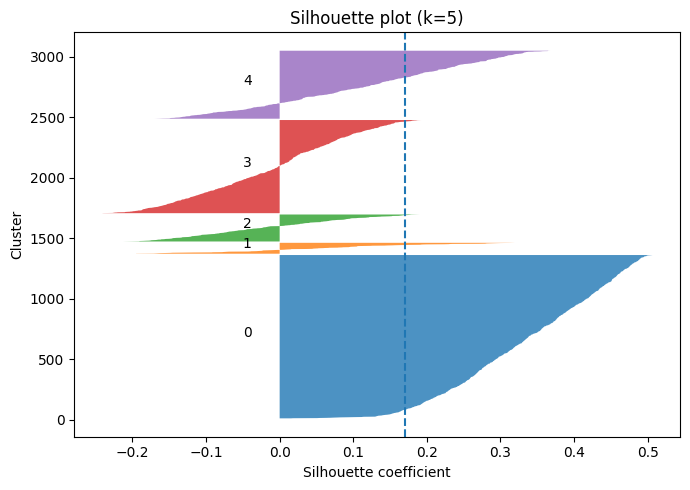

In [122]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

k_final = 5
n_comp = 13
X_cluster = X_pca_full[:, :n_comp]

kmeans = KMeans(n_clusters=k_final, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_cluster)

print("Final silhouette:", round(silhouette_score(X_cluster, labels), 3))

# Cluster sizes
sizes = pd.Series(labels).value_counts().sort_index()
print("\nCluster sizes:")
print(sizes)

# Silhouette plot
sil_vals = silhouette_samples(X_cluster, labels)
y_lower = 10

plt.figure(figsize=(7,5))
for i in range(k_final):
    ith = sil_vals[labels == i]
    ith.sort()
    y_upper = y_lower + len(ith)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, alpha=0.8)
    plt.text(-0.05, y_lower + 0.5*len(ith), str(i))
    y_lower = y_upper + 10

plt.axvline(silhouette_score(X_cluster, labels), linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette plot (k=5)")
plt.tight_layout()
plt.show()

Attaching clusters to customers and creating the required segment CSV



In [123]:
#Attaching labels and creating submission CSV

import pandas as pd

df_segments = df_feat[["customer_number"]].copy()
df_segments["cluster"] = labels


cluster_to_name = {i: f"Customer clutter {i+1}" for i in sorted(df_segments["cluster"].unique())}
df_segments["segment_name"] = df_segments["cluster"].map(cluster_to_name)

display(df_segments.head())

# Save mapping CSV
out_path = "customer_segments.csv"
df_segments[["customer_number", "segment_name"]].to_csv(out_path, index=False)
print("Saved:", out_path)

,customer_number,cluster,segment_name
0,4749,0,Customer clutter 1
1,4757,0,Customer clutter 1
2,144,0,Customer clutter 1
3,572,0,Customer clutter 1
4,669,0,Customer clutter 1


Saved: customer_segments.csv


**Cluster size table**

In [124]:
#Cluster sizes + percentage share

import pandas as pd

size_tbl = (
    df_segments["segment_name"]
    .value_counts()
    .rename_axis("segment_name")
    .reset_index(name="n_customers")
)
size_tbl["pct_customers"] = (size_tbl["n_customers"] / size_tbl["n_customers"].sum() * 100).round(1)

display(size_tbl)

,segment_name,n_customers,pct_customers
0,Customer clutter 1,1351,45.0
1,Customer clutter 4,771,25.7
2,Customer clutter 5,563,18.8
3,Customer clutter 3,224,7.5
4,Customer clutter 2,91,3.0


Profiling table (mean + median of key features)

In [125]:
# profiling dataset: features + segment
df_profile = df_feat.copy()
df_profile["segment_name"] = df_segments["segment_name"].values

key_kpis = [
    "n_baskets", "recency_days",
    "total_basket_spend", "avg_basket_spend", "max_basket_spend",
    "total_basket_qty", "avg_basket_qty",
    "avg_basket_categories",
    "fruit_veg", "dairy", "grocery_food", "confectionary",
    "drinks", "tobacco", "lottery", "cashpoint",
    "bakery"
]

# Keeping only columns that exist
key_kpis = [c for c in key_kpis if c in df_profile.columns]

prof_mean = df_profile.groupby("segment_name")[key_kpis].mean().round(2)
prof_med  = df_profile.groupby("segment_name")[key_kpis].median().round(2)

print("Mean profile:")
display(prof_mean)

print("Median profile:")
display(prof_med)

Mean profile:


,n_baskets,recency_days,total_basket_spend,avg_basket_spend,max_basket_spend,total_basket_qty,avg_basket_qty,avg_basket_categories,fruit_veg,dairy,grocery_food,confectionary,drinks,tobacco,lottery,cashpoint,bakery
segment_name,,,,,,,,,,,,,,,,,
Customer clutter 1,45.34,11.80,414.65,10.63,32.11,310.52,7.91,4.00,36.07,38.96,30.26,29.12,42.47,55.72,6.71,26.89,21.12
Customer clutter 2,61.77,3.51,2157.55,44.79,112.04,1680.15,34.59,7.63,254.99,214.84,216.32,203.93,104.02,71.80,7.30,26.60,113.16
Customer clutter 3,126.75,1.91,1755.98,15.78,56.27,1338.00,12.08,5.25,139.32,150.71,130.66,129.12,123.17,268.03,32.65,77.16,85.91
Customer clutter 4,106.45,1.90,962.90,10.04,39.00,713.29,7.43,4.04,74.36,83.67,61.69,63.57,84.60,150.49,30.83,86.11,47.69
Customer clutter 5,32.33,11.03,740.82,26.11,66.01,584.64,20.52,6.56,85.08,77.18,75.72,64.31,48.08,35.12,3.48,24.11,35.15


Median profile:


,n_baskets,recency_days,total_basket_spend,avg_basket_spend,max_basket_spend,total_basket_qty,avg_basket_qty,avg_basket_categories,fruit_veg,dairy,grocery_food,confectionary,drinks,tobacco,lottery,cashpoint,bakery
segment_name,,,,,,,,,,,,,,,,,
Customer clutter 1,42.0,3.0,403.68,9.84,28.05,308.0,7.28,3.88,27.48,33.69,23.12,24.24,8.40,0.00,0.0,0.0,17.36
Customer clutter 2,48.0,1.0,1951.11,38.77,103.37,1563.0,29.16,7.36,228.87,206.10,206.99,170.86,51.69,0.00,0.0,0.0,97.71
Customer clutter 3,115.0,0.0,1598.58,14.52,51.36,1262.5,11.09,5.04,120.42,135.59,122.42,117.51,22.15,82.22,2.0,10.0,75.27
Customer clutter 4,96.0,0.0,886.56,9.31,31.92,693.0,7.17,3.95,65.15,77.20,54.31,57.52,14.20,13.43,1.0,10.0,42.10
Customer clutter 5,31.0,3.0,723.87,23.50,59.61,586.0,18.11,6.39,74.62,71.47,69.65,55.71,17.68,0.00,0.0,0.0,29.43


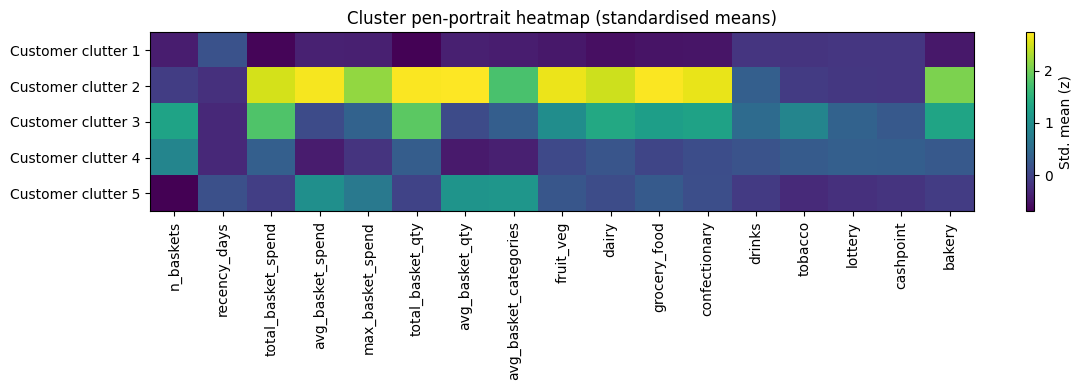

In [126]:
#Heatmap of standardised cluster means (relative differences)

import numpy as np
import matplotlib.pyplot as plt

Z = df_profile[key_kpis].copy()

# Standardise across all customers (z-scores)
Z = (Z - Z.mean()) / Z.std(ddof=0)

Z["segment_name"] = df_profile["segment_name"].values
Z_means = Z.groupby("segment_name")[key_kpis].mean()

plt.figure(figsize=(12, 4))
plt.imshow(Z_means, aspect="auto")
plt.yticks(range(len(Z_means.index)), Z_means.index)
plt.xticks(range(len(key_kpis)), key_kpis, rotation=90)
plt.colorbar(label="Std. mean (z)")
plt.title("Cluster pen-portrait heatmap (standardised means)")
plt.tight_layout()
plt.show()

**Creating the visual : PCA scatter by cluster**

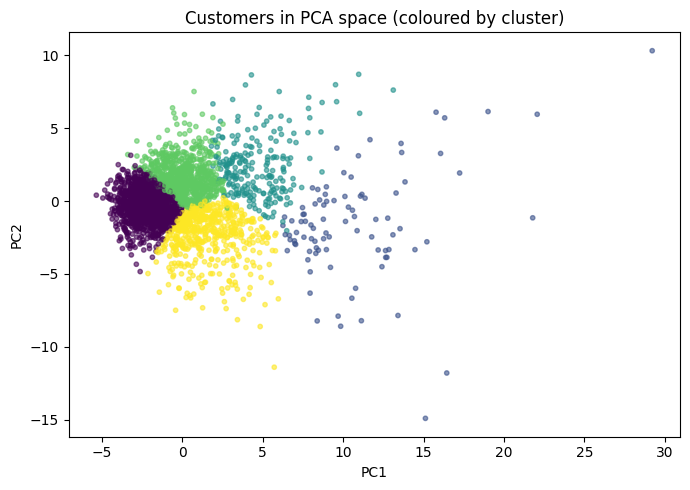

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# Use first two PCA components for a simple visual
pc1 = X_pca_full[:, 0]
pc2 = X_pca_full[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(pc1, pc2, c=labels, s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA space (coloured by cluster)")
plt.tight_layout()
plt.show()

In [128]:
# Saving profiling outputs for report appendix

size_tbl.to_csv("segment_sizes.csv", index=False)
prof_mean.to_csv("segment_profile_mean.csv")
prof_med.to_csv("segment_profile_median.csv")

print("Saved: segment_sizes.csv, segment_profile_mean.csv, segment_profile_median.csv")

Saved: segment_sizes.csv, segment_profile_mean.csv, segment_profile_median.csv


In [129]:
#Final submission file
df_segments[["customer_number", "segment_name"]].to_csv("customer_segments.csv", index=False)
print("Saved final submission file: customer_segments.csv")

Saved final submission file: customer_segments.csv


In [130]:
out = df_segments.copy()
out["segment_id"] = out["segment_name"].str.extract(r"(\d+)$").astype(int)  # 1..5
out = out.rename(columns={"customer_number": "customer_id"})  # optional wording match

out[["customer_id", "segment_id", "segment_name"]].to_csv("customer_segments_final.csv", index=False)
print("Saved: customer_segments_final.csv")

Saved: customer_segments_final.csv


In [131]:
from google.colab import files
files.download("customer_segments_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Ensuring the feature list exactly matches dataframe (no missing/extra columns)**

In [132]:
print(X.columns.tolist())
print("Number of features:", X.shape[1])

['n_baskets', 'total_basket_qty', 'avg_basket_qty', 'std_basket_qty', 'total_basket_spend', 'avg_basket_spend', 'std_basket_spend', 'max_basket_spend', 'avg_basket_categories', 'std_basket_categories', 'recency_days', 'fruit_veg', 'dairy', 'confectionary', 'grocery_food', 'grocery_health_pets', 'bakery', 'newspapers_magazines', 'prepared_meals', 'soft_drinks', 'frozen', 'meat', 'tobacco', 'drinks', 'deli', 'world_foods', 'lottery', 'cashpoint', 'seasonal_gifting', 'discount_bakery', 'practical_items']
Number of features: 31


**small appendix table for the bakery correction**

In [133]:
# Appendix evidence: bakery correction summary
diff = (df_category["bakery"] - df_category["bakery_original"]).abs()
bakery_audit = pd.DataFrame({
    "metric": [
        "customers_total",
        "customers_changed",
        "pct_changed",
        "bakery_original_mean",
        "bakery_corrected_mean"
    ],
    "value": [
        len(df_category),
        int((diff > 1e-6).sum()),
        round((diff > 1e-6).mean() * 100, 1),
        round(df_category["bakery_original"].mean(), 2),
        round(df_category["bakery"].mean(), 2),
    ]
})
display(bakery_audit)

,metric,value
0,customers_total,3000.00
1,customers_changed,2963.00
2,pct_changed,98.80
3,bakery_original_mean,0.00
4,bakery_corrected_mean,38.21


 Visuals

**1) Frequency distribution (n_baskets)**

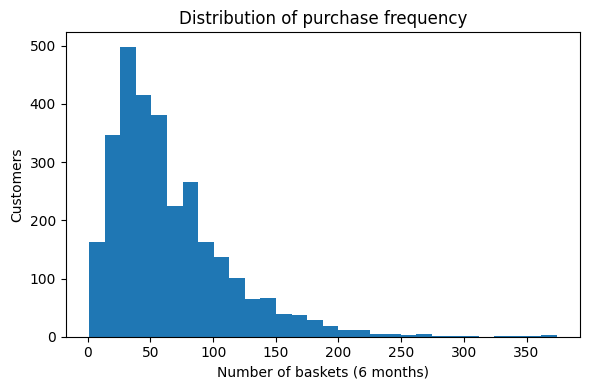

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_feat["n_baskets"], bins=30)
plt.xlabel("Number of baskets (6 months)")
plt.ylabel("Customers")
plt.title("Distribution of purchase frequency")
plt.tight_layout()
plt.show()

**2) Basket spend distribution (avg_basket_spend)**

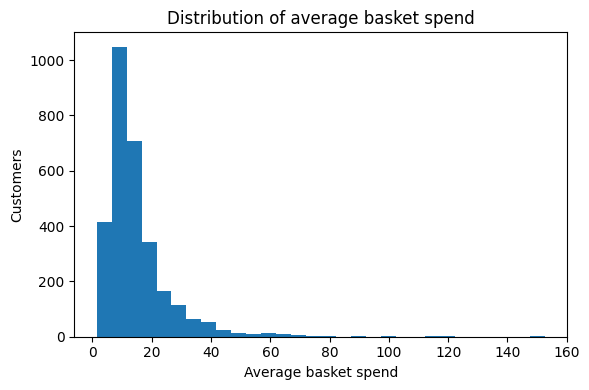

In [135]:
plt.figure(figsize=(6,4))
plt.hist(df_feat["avg_basket_spend"], bins=30)
plt.xlabel("Average basket spend")
plt.ylabel("Customers")
plt.title("Distribution of average basket spend")
plt.tight_layout()
plt.show()

**3) Recency distribution (recency_days)**

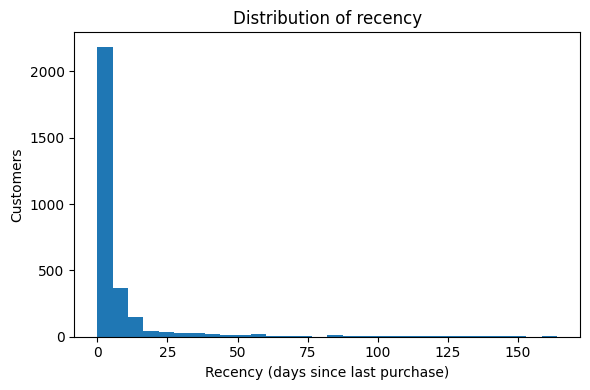

In [136]:
plt.figure(figsize=(6,4))
plt.hist(df_feat["recency_days"], bins=30)
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Customers")
plt.title("Distribution of recency")
plt.tight_layout()
plt.show()

**4) Top categories by total spend**

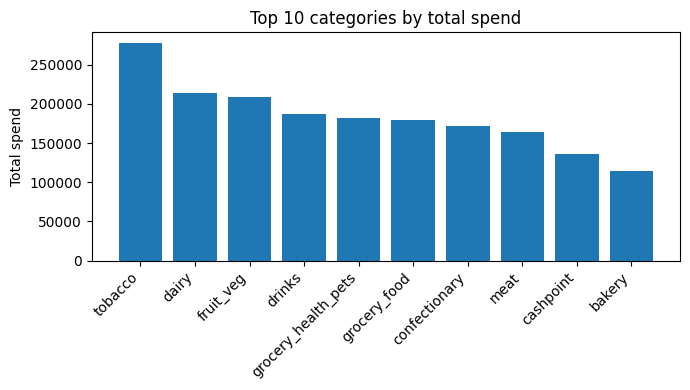

In [137]:
cat_cols = [
    'fruit_veg','dairy','confectionary','grocery_food','grocery_health_pets','bakery',
    'newspapers_magazines','prepared_meals','soft_drinks','frozen','meat','tobacco',
    'drinks','deli','world_foods','lottery','cashpoint','seasonal_gifting',
    'discount_bakery','practical_items'
]

totals = df_feat[cat_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(7,4))
plt.bar(totals.index, totals.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total spend")
plt.title("Top 10 categories by total spend")
plt.tight_layout()
plt.show()

In [138]:
# Reordering cluster labels by mean total_basket_spend (ascending)
seg_spend = df_profile.groupby("segment_name")["total_basket_spend"].mean().sort_values()
display(seg_spend)

,total_basket_spend
segment_name,
Customer clutter 1,414.651902
Customer clutter 5,740.818224
Customer clutter 4,962.896252
Customer clutter 3,1755.979911
Customer clutter 2,2157.548901


 Create a “pen portrait” table


In [139]:
#One-page pen portrait table (key KPIs only)

pen = df_profile.groupby("segment_name").agg(
    n_customers=("segment_name","size"),
    recency_days=("recency_days","mean"),
    n_baskets=("n_baskets","mean"),
    avg_basket_spend=("avg_basket_spend","mean"),
    total_basket_spend=("total_basket_spend","mean"),
    avg_basket_qty=("avg_basket_qty","mean"),
    avg_basket_categories=("avg_basket_categories","mean"),
    tobacco=("tobacco","mean"),
    cashpoint=("cashpoint","mean"),
    lottery=("lottery","mean"),
    bakery=("bakery","mean")
).round(2)

pen["pct_customers"] = (pen["n_customers"] / pen["n_customers"].sum() * 100).round(1)
pen = pen[["n_customers","pct_customers","recency_days","n_baskets","avg_basket_spend","total_basket_spend",
           "avg_basket_qty","avg_basket_categories","bakery","tobacco","lottery","cashpoint"]]

display(pen)
pen.to_csv("pen_portrait_table.csv")
print("Saved: pen_portrait_table.csv")

,n_customers,pct_customers,recency_days,n_baskets,avg_basket_spend,total_basket_spend,avg_basket_qty,avg_basket_categories,bakery,tobacco,lottery,cashpoint
segment_name,,,,,,,,,,,,
Customer clutter 1,1351,45.0,11.80,45.34,10.63,414.65,7.91,4.00,21.12,55.72,6.71,26.89
Customer clutter 2,91,3.0,3.51,61.77,44.79,2157.55,34.59,7.63,113.16,71.80,7.30,26.60
Customer clutter 3,224,7.5,1.91,126.75,15.78,1755.98,12.08,5.25,85.91,268.03,32.65,77.16
Customer clutter 4,771,25.7,1.90,106.45,10.04,962.90,7.43,4.04,47.69,150.49,30.83,86.11
Customer clutter 5,563,18.8,11.03,32.33,26.11,740.82,20.52,6.56,35.15,35.12,3.48,24.11


Saved: pen_portrait_table.csv
